# California Housing Price Prediction Project

This notebook work as a project workflow for predicting `median_house_value` from demographic, geographic, and housing-related features in the California housing dataset.

## Project workflow
1. Acquire and load the data  
2. Explore the dataset and visualize key patterns  
3. Build a stratified train/test split  
4. Prepare the data with preprocessing pipelines and feature engineering  
5. Train and compare several regression models  
6. Tune the strongest models  
7. Interpret feature importance and evaluate on the held-out test set


## 1. Data Acquisition and Loading


In [1]:
# Import libraries and define helper functions to download and load the California housing dataset.
import os
import tarfile
import warnings
from six.moves import urllib

import numpy as np
import pandas as pd

warnings.filterwarnings(action="ignore", message="^internal gelsd")

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)


In [2]:
# Download the raw data (if needed) and load it into a pandas DataFrame.
fetch_housing_data()
housing = load_housing_data()
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploratory Data Analysis


In [3]:
# Inspect the table structure, data types, missing values, and a few basic descriptive summaries.
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Summarize category frequencies and descriptive statistics to understand the dataset at a high level.
display(housing["ocean_proximity"].value_counts())
display(housing.describe())


<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Configure plotting settings so that all visualizations render clearly inside the notebook.
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rc("axes", labelsize=12)
mpl.rc("xtick", labelsize=10)
mpl.rc("ytick", labelsize=10)


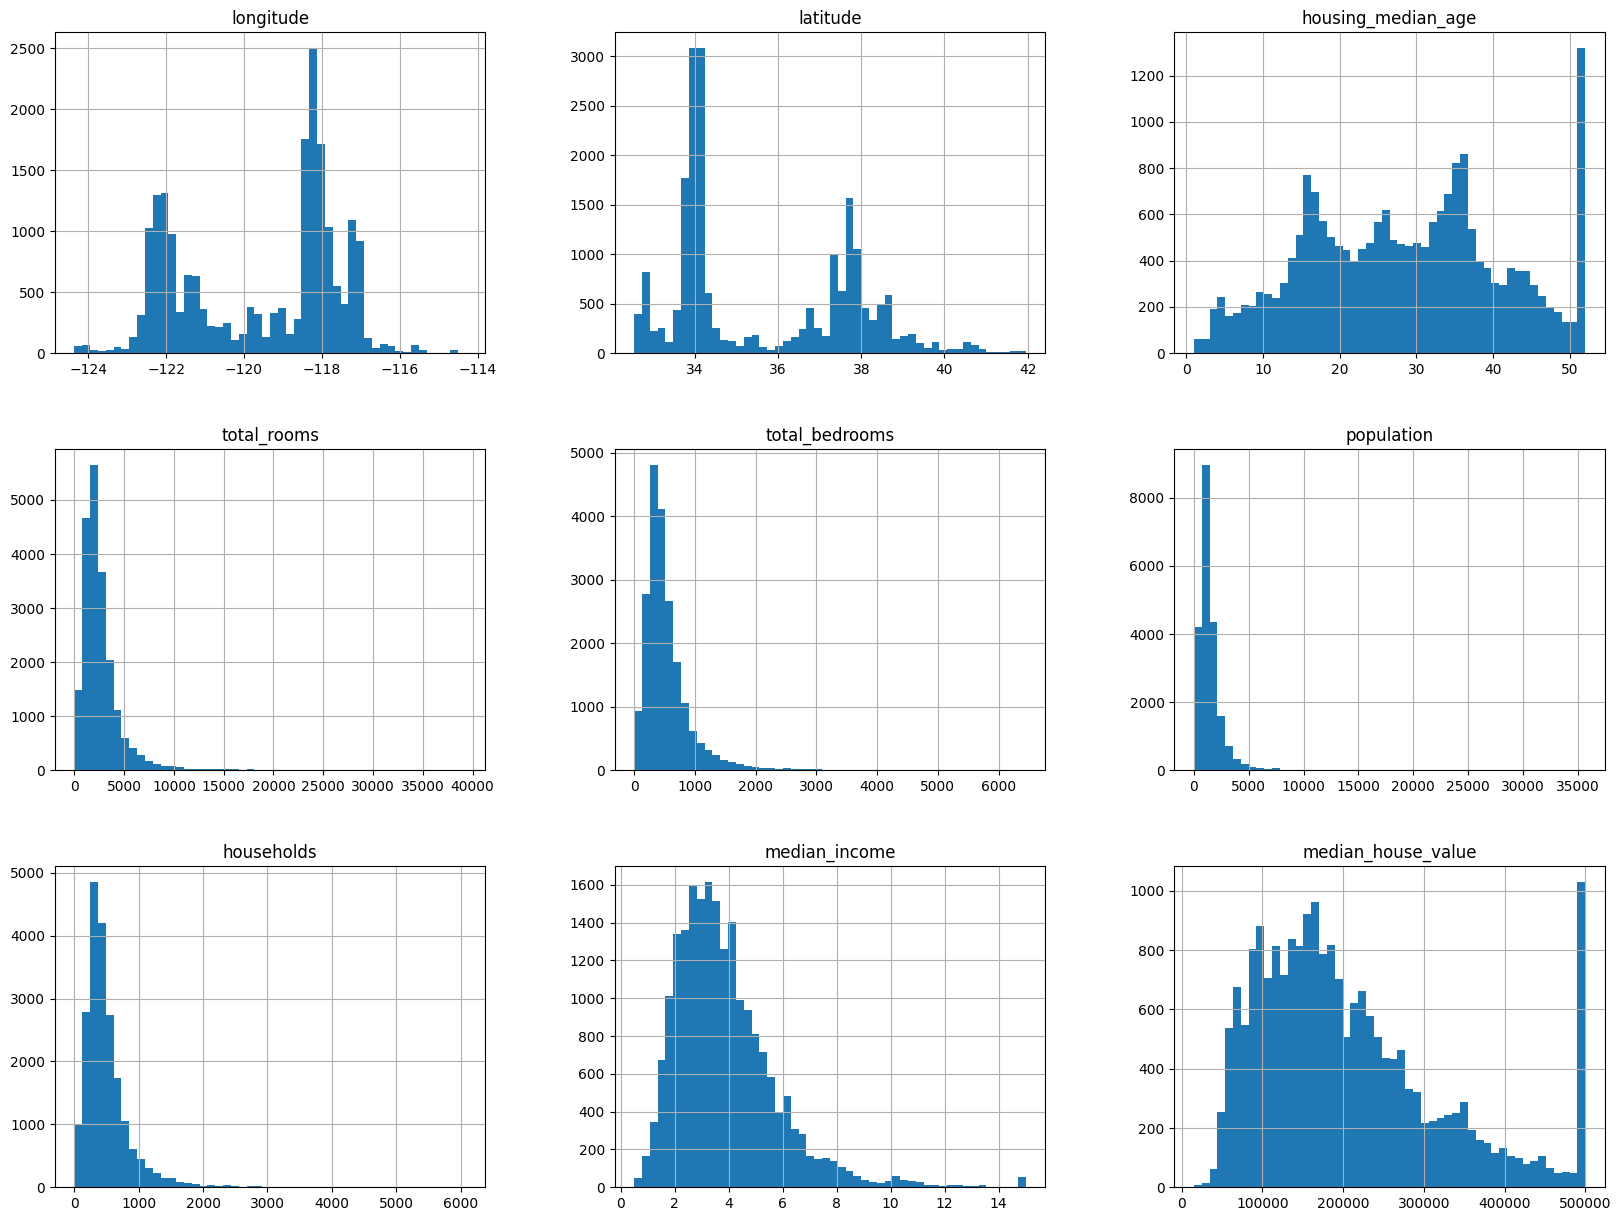

In [6]:
# Plot histograms for the numerical features to inspect scale, skewness, and potential outliers.
housing.hist(bins=50, figsize=(20, 15))
plt.show()


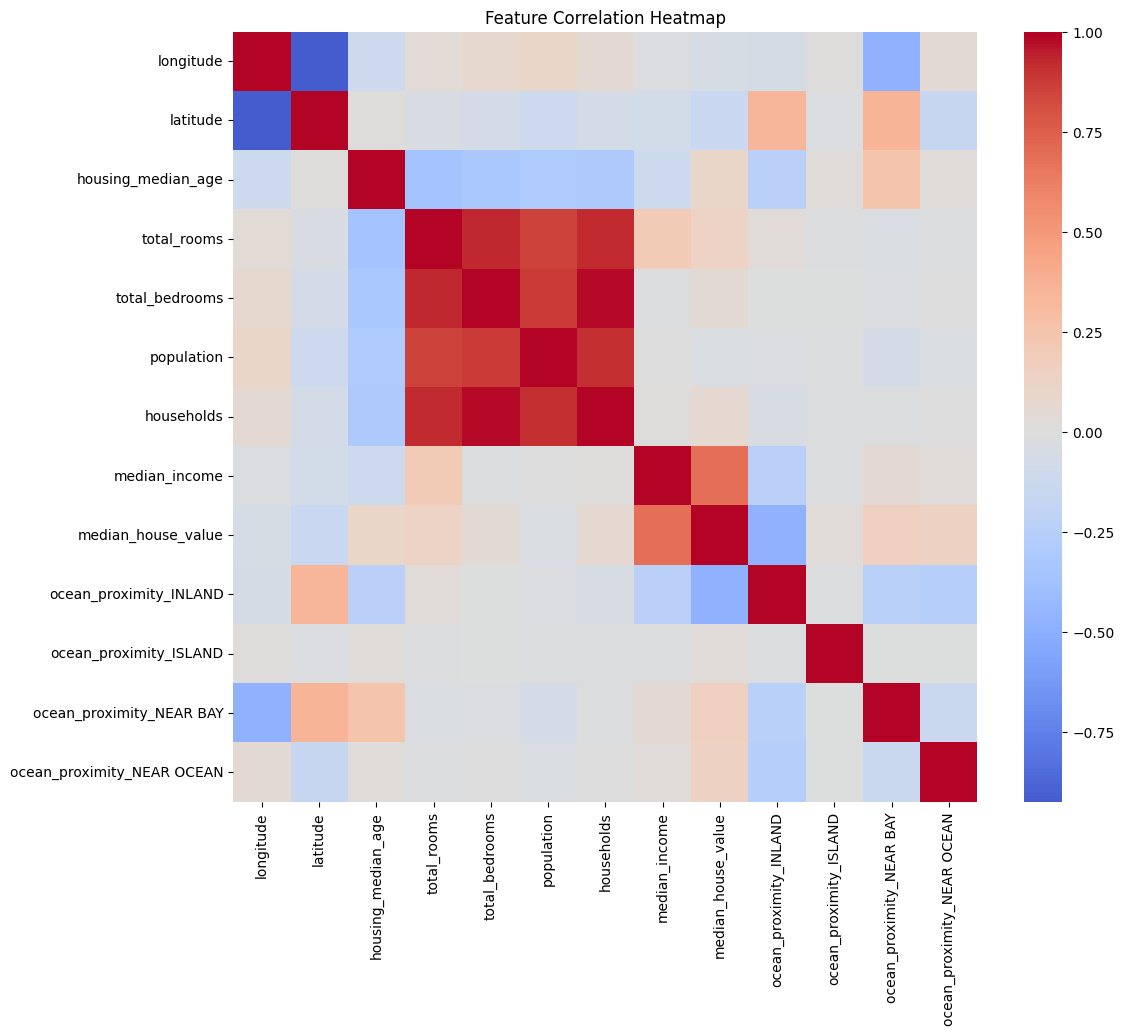

In [7]:
# Convert the categorical location variable to numeric dummies so we can examine the full correlation matrix.
housing_corr_ready = pd.get_dummies(housing, columns=["ocean_proximity"], drop_first=True)
corr = housing_corr_ready.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [8]:
# Rank the features by their linear correlation with the target variable.
corr["median_house_value"].sort_values(ascending=False)


median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049686
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64

## 3. Train/Test Split Strategy


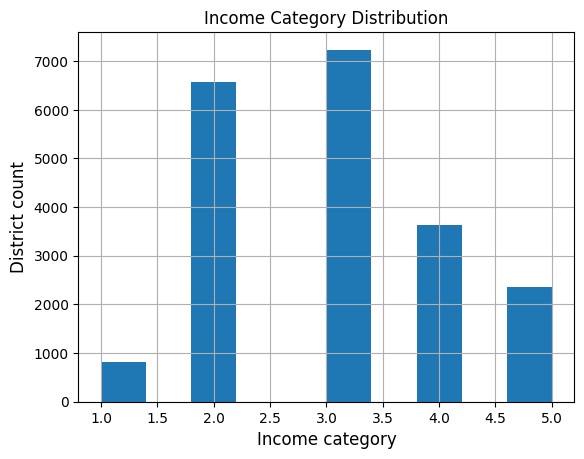

In [9]:
# Create an income category so the train/test split preserves the overall income distribution.
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

housing["income_cat"].hist()
plt.xlabel("Income category")
plt.ylabel("District count")
plt.title("Income Category Distribution")
plt.show()


In [10]:
# Perform a stratified shuffle split based on income category to build stable train and test sets.
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index].copy()
    strat_test_set = housing.loc[test_index].copy()

random_train_set, random_test_set = train_test_split(housing, test_size=0.2, random_state=42)


In [11]:
# Compare overall, stratified, and ordinary random sampling proportions to verify the split quality.
def income_cat_proportions(data):
    return data["income_cat"].value_counts().sort_index() / len(data)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(random_test_set),
})

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
compare_props


,Overall,Stratified,Random,Rand. %error,Strat. %error
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [12]:
# Remove the helper stratification column now that the final train/test split has been created.
for dataset in (strat_train_set, strat_test_set):
    dataset.drop("income_cat", axis=1, inplace=True)

housing = strat_train_set.copy()


## 4. Geospatial Analysis


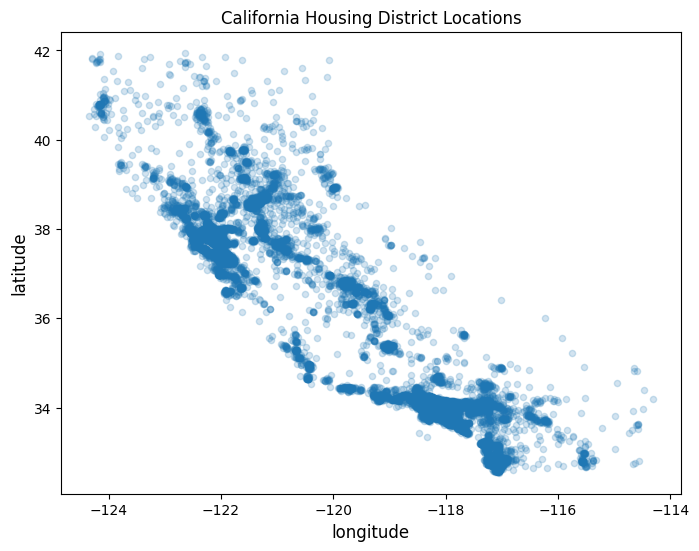

In [13]:
# Plot the district locations to see the geographic coverage of the training data.
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2, figsize=(8, 6))
plt.title("California Housing District Locations")
plt.show()


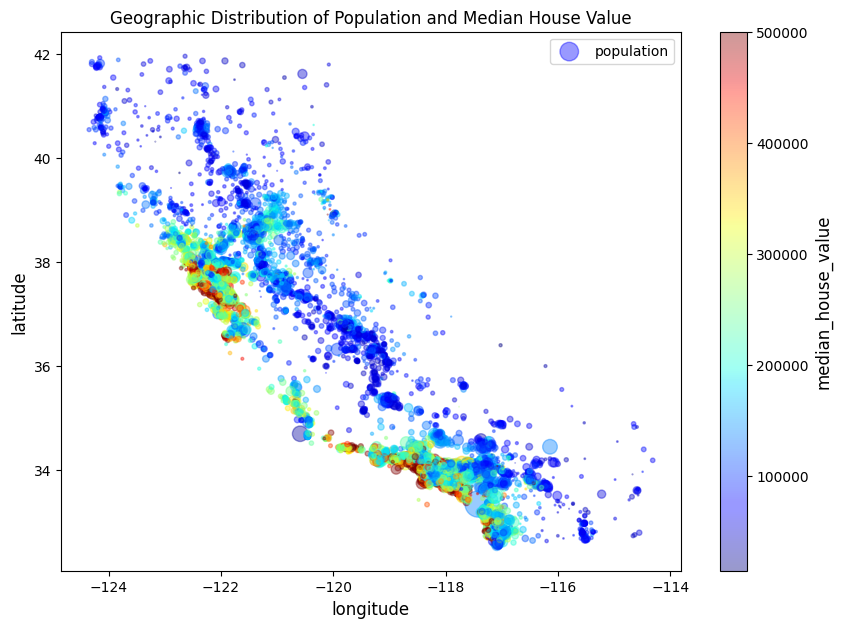

In [14]:
# Build an enhanced geographic plot where point size reflects population and color reflects house value.
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    label="population",
    figsize=(10, 7),
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
    sharex=False,
)
plt.legend()
plt.title("Geographic Distribution of Population and Median House Value")
plt.show()


## 5. Data Preparation and Feature Engineering


In [15]:
# Separate predictors from the target so all preprocessing is learned only from the training features.
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()


In [16]:
# Fit a median imputer on the numerical columns and preview the imputed numeric feature matrix.
from sklearn.impute import SimpleImputer

housing_num = housing.select_dtypes(include=[np.number])
imputer = SimpleImputer(strategy="median")
housing_num_imputed = pd.DataFrame(
    imputer.fit_transform(housing_num),
    columns=housing_num.columns,
    index=housing_num.index,
)
housing_num_imputed.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


In [17]:
# Inspect the categorical feature and prepare to encode it using one-hot encoding.
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

display(housing_cat.head())
display(cat_encoder.categories_)


,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [18]:
# Define a custom transformer that adds useful ratio-based housing features for model training.
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = [
    list(housing.columns).index(col)
    for col in ("total_rooms", "total_bedrooms", "population", "households")
]

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]

        return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=True)


In [19]:
# Preview the engineered features before they are inserted into the final preprocessing pipeline.
housing_extra_attribs = pd.DataFrame(
    attr_adder.transform(housing.values),
    columns=list(housing.columns) + [
        "rooms_per_household",
        "population_per_household",
        "bedrooms_per_room",
    ],
    index=housing.index,
)
housing_extra_attribs.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,3.168555,0.205784
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,2.623698,0.160714
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.875,INLAND,5.393333,2.223333,0.191595
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,3.886128,1.859213,0.276505
20496,-118.7,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,6.096552,3.167241,0.182692


In [20]:
# Build a numeric preprocessing pipeline that imputes missing values, adds engineered features, and standardizes inputs.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler()),
])

housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_num_tr[:3]


array([[-0.94135046,  1.34743822,  0.02756357,  0.58477745,  0.64037127,
         0.73260236,  0.55628602, -0.8936472 ,  0.01739526,  0.00622264,
        -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763,  1.26146668,  0.78156132,
         0.53361152,  0.72131799,  1.292168  ,  0.56925554, -0.04081077,
        -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, -0.46977281, -0.54513828,
        -0.67467519, -0.52440722, -0.52543365, -0.01802432, -0.07537122,
        -0.33827252]])

In [21]:
# Combine the numeric pipeline with one-hot encoding so the full dataset can be transformed consistently.
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared.shape


(16512, 16)

## 6. Baseline and Candidate Models


In [22]:
# Train a linear regression baseline on the fully prepared training matrix.
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)


LinearRegression()

In [23]:
# Compare a few linear regression predictions against the true labels as a quick sanity check.
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:     ", list(some_labels))


Predictions: [ 85120. 305856. 152256. 186624. 244480.]
Labels:      [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [24]:
# Compute in-sample RMSE and MAE for the linear regression baseline.
from sklearn.metrics import mean_absolute_error, mean_squared_error

lin_predictions = lin_reg.predict(housing_prepared)
lin_rmse = np.sqrt(mean_squared_error(housing_labels, lin_predictions))
lin_mae = mean_absolute_error(housing_labels, lin_predictions)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression MAE: ", lin_mae)


Linear Regression RMSE: 68634.44789635955
Linear Regression MAE:  49466.61415939922


In [25]:
# Define a reusable helper to evaluate each candidate model with cross-validation.
from sklearn.model_selection import cross_val_score

def display_rmse_scores(model, X, y, cv=10):
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse_scores = np.sqrt(-scores)
    print("Scores:", rmse_scores)
    print("Mean:", rmse_scores.mean())
    print("Standard deviation:", rmse_scores.std())
    return rmse_scores


In [26]:
# Evaluate linear regression with cross-validation to estimate its out-of-sample performance.
lin_rmse_scores = display_rmse_scores(lin_reg, housing_prepared, housing_labels)


Scores: [71778.64956897 64114.99166359 67771.17124356 68613.18677014
 66828.8611363  72551.43826898 73997.08050233 68830.50397661
 66443.28836884 70144.65874699]
Mean: 69107.38302462916
Standard deviation: 2886.202548783683


In [27]:
# Train a decision tree regressor and evaluate it with cross-validation to check for overfitting.
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

tree_train_rmse = np.sqrt(mean_squared_error(housing_labels, tree_reg.predict(housing_prepared)))
print("Decision Tree training RMSE:", tree_train_rmse)

tree_rmse_scores = display_rmse_scores(tree_reg, housing_prepared, housing_labels)


Decision Tree training RMSE: 0.0
Scores: [72831.45749112 69973.18438322 69528.56551415 72517.78229792
 69145.50006909 79094.74123727 68960.045444   73344.50225684
 69826.02473916 71077.09753998]
Mean: 71629.89009727491
Standard deviation: 2914.035468468928


In [28]:
# Train a random forest regressor and evaluate it with cross-validation as a stronger non-linear benchmark.
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

forest_train_rmse = np.sqrt(mean_squared_error(housing_labels, forest_reg.predict(housing_prepared)))
print("Random Forest training RMSE:", forest_train_rmse)

forest_rmse_scores = display_rmse_scores(forest_reg, housing_prepared, housing_labels)


Random Forest training RMSE: 22413.454658589766
Scores: [53519.05518628 50467.33817051 48924.16513902 53771.72056856
 50810.90996358 54876.09682033 56012.79985518 52256.88927227
 51527.73185039 55762.56008531]
Mean: 52792.92669114079
Standard deviation: 2262.8151900582


In [29]:
# Try a linear-kernel support vector regressor over several C values to test another model family.
from sklearn.svm import SVR

for C in [0.1, 1, 10, 100]:
    svm_reg = SVR(kernel="linear", C=C)
    scores = cross_val_score(
        svm_reg,
        housing_prepared,
        housing_labels,
        scoring="neg_mean_squared_error",
        cv=5,
    )
    rmse_scores = np.sqrt(-scores)
    print(f"Linear SVR (C={C}) mean RMSE: {rmse_scores.mean():.2f}")


Linear SVR (C=0.1) mean RMSE: 118255.76
Linear SVR (C=1) mean RMSE: 112567.69
Linear SVR (C=10) mean RMSE: 84643.74
Linear SVR (C=100) mean RMSE: 71623.73


In [30]:
# Try an RBF-kernel support vector regressor over several C and gamma combinations.
for C in [1, 10, 100]:
    for gamma in [0.01, 0.1, 1]:
        svm_reg = SVR(kernel="rbf", C=C, gamma=gamma)
        scores = cross_val_score(
            svm_reg,
            housing_prepared,
            housing_labels,
            scoring="neg_mean_squared_error",
            cv=5,
        )
        rmse_scores = np.sqrt(-scores)
        print(f"RBF SVR (C={C}, gamma={gamma}) mean RMSE: {rmse_scores.mean():.2f}")


RBF SVR (C=1, gamma=0.01) mean RMSE: 118816.29
RBF SVR (C=1, gamma=0.1) mean RMSE: 118640.56
RBF SVR (C=1, gamma=1) mean RMSE: 118895.80
RBF SVR (C=10, gamma=0.01) mean RMSE: 117859.09
RBF SVR (C=10, gamma=0.1) mean RMSE: 116177.96
RBF SVR (C=10, gamma=1) mean RMSE: 118588.60
RBF SVR (C=100, gamma=0.01) mean RMSE: 109132.76
RBF SVR (C=100, gamma=0.1) mean RMSE: 98570.29
RBF SVR (C=100, gamma=1) mean RMSE: 115836.84


## 7. Hyperparameter Tuning


In [31]:
# Run a grid search on the random forest model to systematically test a small hyperparameter grid.
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True,
)
grid_search.fit(housing_prepared, housing_labels)

print("Grid Search best params:", grid_search.best_params_)
print("Grid Search best CV RMSE:", np.sqrt(-grid_search.best_score_))


Grid Search best params: {'max_features': 8, 'n_estimators': 30}
Grid Search best CV RMSE: 49898.98913455217


In [32]:
# Review the grid-search results for every tested parameter combination.
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results[["params", "mean_test_score", "rank_test_score"]].assign(
    mean_test_rmse=lambda df: np.sqrt(-df["mean_test_score"])
).sort_values("rank_test_score").head(10)


,params,mean_test_score,rank_test_score,mean_test_rmse
11,"{'max_features': 8, 'n_estimators': 30}",-2.489909e+09,1,49898.989135
8,"{'max_features': 6, 'n_estimators': 30}",-2.496981e+09,2,49969.804416
5,"{'max_features': 4, 'n_estimators': 30}",-2.518759e+09,3,50187.243249
17,"{'bootstrap': False, 'max_features': 4, 'n_est...",-2.629472e+09,4,51278.378771
7,"{'max_features': 6, 'n_estimators': 10}",-2.654240e+09,5,51519.320624
10,"{'max_features': 8, 'n_estimators': 10}",-2.752030e+09,6,52459.796247
4,"{'max_features': 4, 'n_estimators': 10}",-2.755726e+09,7,52495.012850
15,"{'bootstrap': False, 'max_features': 3, 'n_est...",-2.783044e+09,8,52754.563281
2,"{'max_features': 2, 'n_estimators': 30}",-2.796915e+09,9,52885.867153
13,"{'bootstrap': False, 'max_features': 2, 'n_est...",-2.967697e+09,10,54476.570509


In [33]:
# Run a randomized search on the random forest model to explore a wider hyperparameter space efficiently.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(10, 201),
    "max_features": randint(2, 9),
    "bootstrap": [True, False],
}

random_forest = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(
    random_forest,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)
rnd_search.fit(housing_prepared, housing_labels)

print("Randomized Search best params:", rnd_search.best_params_)
print("Randomized Search best CV RMSE:", np.sqrt(-rnd_search.best_score_))


Randomized Search best params: {'bootstrap': False, 'max_features': 4, 'n_estimators': 159}
Randomized Search best CV RMSE: 48628.96439501363


In [34]:
# Compare the best grid-search and randomized-search results side by side.
search_comparison = pd.DataFrame({
    "Search Method": ["GridSearchCV", "RandomizedSearchCV"],
    "Best CV RMSE": [np.sqrt(-grid_search.best_score_), np.sqrt(-rnd_search.best_score_)],
    "Best Params": [str(grid_search.best_params_), str(rnd_search.best_params_)],
})

search_comparison


,Search Method,Best CV RMSE,Best Params
0,GridSearchCV,49898.989135,"{'max_features': 8, 'n_estimators': 30}"
1,RandomizedSearchCV,48628.964395,"{'bootstrap': False, 'max_features': 4, 'n_est..."


## 8. Model Interpretation and Final Evaluation


In [35]:
# Extract and rank feature importances from the best grid-search random forest model.
feature_importances = grid_search.best_estimator_.feature_importances_

extra_attribs = ["rooms_per_household", "population_per_household", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

sorted(zip(feature_importances, attributes), reverse=True)[:15]


[(0.3790092248170967, 'median_income'),
 (0.16570630316895876, 'INLAND'),
 (0.10703132208204354, 'population_per_household'),
 (0.06965425227942929, 'longitude'),
 (0.0604213840080722, 'latitude'),
 (0.05477891501828372, 'rooms_per_household'),
 (0.048203121338269206, 'bedrooms_per_room'),
 (0.04218822024391753, 'housing_median_age'),
 (0.015849114744428634, 'population'),
 (0.015554529490469328, 'total_bedrooms'),
 (0.01524505568840977, 'total_rooms'),
 (0.014934655161887774, 'households'),
 (0.006792660074259966, '<1H OCEAN'),
 (0.0030281610628962747, 'NEAR OCEAN'),
 (0.0015247327555504937, 'NEAR BAY')]

In [36]:
# Select the stronger tuned model and evaluate it once on the held-out stratified test set.
best_search = rnd_search if rnd_search.best_score_ > grid_search.best_score_ else grid_search
final_model = best_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print("Chosen search method:", type(best_search).__name__)
print("Final test RMSE:", final_rmse)


Chosen search method: RandomizedSearchCV
Final test RMSE: 46176.56023892277


In [37]:
# Compute a 95% confidence interval for the model's test RMSE using the squared prediction errors.
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
m = len(squared_errors)

rmse_confidence_interval = np.sqrt(
    stats.t.interval(
        confidence,
        m - 1,
        loc=np.mean(squared_errors),
        scale=stats.sem(squared_errors),
    )
)

rmse_confidence_interval


array([44236.92987178, 48037.93778377])